# Delhi Metro Network Analysis

Analysing the metro network in a city like delhi helps improve urban transpotation infrastructure, leading to better city planning and enhanced commuter experienced. 

# Importing the packages

In [1]:
import pandas as pd
import requests
import folium
import networkx as nx
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading the dataset
data=pd.read_csv("Delhi_Metro_Network_Analysis.csv")

In [3]:
#First 10 rows of the dataset
data.head(10)

,ID (Station ID),Station Names,Dist. From First Station(km),Line,Opening Date,Layout,Latitude,Longitude
0,1,Shaheed Sthal(First Station),0.0,Red line,8/3/2019,Elevated,28.670611,77.415582
1,2,Hindon River,1.0,Red line,8/3/2019,Elevated,28.878965,77.415483
2,3,Arthala,2.5,Red line,8/3/2019,Elevated,28.676999,77.391892
3,4,Mohan Nagar,3.2,Red line,8/3/2019,Elevated,28.606319,77.106082
4,5,Shyam park,4.5,Red line,8/3/2019,Elevated,28.698807,28.698807
5,6,Major Mohit Sharma,5.7,Red line,8/3/2019,Elevated,28.677611,77.358143
6,7,Raj Bagh,6.9,Red line,8/3/2019,Elevated,28.640860,77.209500
7,8,Shaheed Nagar,8.2,Red line,8/3/2019,Elevated,28.530780,77.212057
8,9,Dilshad Garden,9.4,Red line,4/6/2008,Elevated,28.675920,77.321420
9,10,Jhil Mil,10.3,Red line,4/6/2008,Elevated,28.675790,77.312390


In [4]:
data.tail(10)

,ID (Station ID),Station Names,Dist. From First Station(km),Line,Opening Date,Layout,Latitude,Longitude
275,21,Depot Greater Noida,27.1,Aqua line,25-01-2019,Elevated,28.474388,77.503990
276,1,Dwarka [Conn: Blue],0.0,Gray line,4/10/2019,Elevated,28.577192,77.044293
277,2,Nangli,1.5,Gray line,4/10/2019,Elevated,28.617300,77.010437
278,3,Najafgarh,3.9,Gray line,4/10/2019,Underground,28.612304,76.982391
279,1,New Delhi-Airport Express [Conn: Yellow],0.0,Orange line,23-02-2011,Underground,28.643070,77.221440
280,2,Shivaji Stadium,1.9,Orange line,23-02-2011,Underground,28.629010,77.211900
281,3,Dhaula Kuan [Conn: Pink],8.3,Orange line,15-08-2011,Elevated,28.591780,77.161550
282,4,Delhi Aerocity,14.5,Orange line,15-08-2011,Underground,28.548810,77.120920
283,5,IGI Airport,17.9,Orange line,23-02-2011,Underground,28.556930,77.086690
284,6,Dwarka Sector 21 [Conn: Blue],20.8,Orange line,23-02-2011,Underground,28.552260,77.058280


## Understaning about the dataset:

The Delhi Metro network dataset provides a rich source of information on one of India's most prominent urban transportation systems. In this comprehensive exploration, we delve into various dimensions of the data to uncover insights into the network's structure, growth, and significance.

The detailed information about the columns that are in the dataset are given below:

1. **StationID**: The ID of the every metro station in the delhi
2. **Station Name**: The name of the metro station in the delhi
3. **Distance from Start (km)**: The distance of the metro station from the line starts in the delhi
4. **Line**: This defines in which line the metro station is in the delhi
5. **Opening Date**: The opening date of the every metro station in the delhi
6. **Station Layout**: Which tells about the metro station is in which layout like eleveted or underground or atgrad.
7. **latitude and longitute**: The latitute and longitute of every metro station in the delhi.

In [5]:
#Shape of the dataset
data.shape

(285, 8)

The Delhi Metro Station dataset conisits of 285 rows means observation and 8 columns.

In [6]:
#Columns of the dataset
data.columns

Index(['ID (Station ID)', 'Station Names', 'Dist. From First Station(km)',
       'Line', 'Opening Date', 'Layout', 'Latitude', 'Longitude'],
      dtype='object')

In [7]:
#Checking the null values
data.isnull().sum()

ID (Station ID)                 0
Station Names                   0
Dist. From First Station(km)    0
Line                            0
Opening Date                    0
Layout                          0
Latitude                        0
Longitude                       0
dtype: int64

- Here we can observe that there is no any null values in the metro station dataset.

In [8]:
#Checking the datatype
data_type=data.dtypes
print(data_type)

ID (Station ID)                   int64
Station Names                    object
Dist. From First Station(km)    float64
Line                             object
Opening Date                     object
Layout                           object
Latitude                        float64
Longitude                       float64
dtype: object


- This will give the data type details of the every column 

In [9]:
#changing the opening date column in datetime format
data["Opening Date"] = pd.to_datetime(data["Opening Date"], dayfirst=True, errors='coerce')

In [10]:
data.head(10)

,ID (Station ID),Station Names,Dist. From First Station(km),Line,Opening Date,Layout,Latitude,Longitude
0,1,Shaheed Sthal(First Station),0.0,Red line,2019-03-08,Elevated,28.670611,77.415582
1,2,Hindon River,1.0,Red line,2019-03-08,Elevated,28.878965,77.415483
2,3,Arthala,2.5,Red line,2019-03-08,Elevated,28.676999,77.391892
3,4,Mohan Nagar,3.2,Red line,2019-03-08,Elevated,28.606319,77.106082
4,5,Shyam park,4.5,Red line,2019-03-08,Elevated,28.698807,28.698807
5,6,Major Mohit Sharma,5.7,Red line,2019-03-08,Elevated,28.677611,77.358143
6,7,Raj Bagh,6.9,Red line,2019-03-08,Elevated,28.640860,77.209500
7,8,Shaheed Nagar,8.2,Red line,2019-03-08,Elevated,28.530780,77.212057
8,9,Dilshad Garden,9.4,Red line,2008-06-04,Elevated,28.675920,77.321420
9,10,Jhil Mil,10.3,Red line,2008-06-04,Elevated,28.675790,77.312390


- to_datetime- it will format the date in the Opening Date.

In [11]:
data.Line.unique()

array(['Red line', 'Yellow line', 'Blue line', 'Blue line branch',
       'Green line branch', 'Green line', 'Rapid Metro', 'Voilet line',
       'Magenta line', 'Pink line', 'Aqua line', 'Gray line',
       'Orange line'], dtype=object)

- These are the different line in the delhi metro

In [12]:
line_colors={'Red line': 'red', 
            'Pink line': 'pink',
            'Rapid Metro': 'black',
            'Magneta line': 'dark red',
            'Blue line': 'blue',
            'Aqua line': 'lightblue',
            'Voilet line': 'purple',
            'Yellow line': 'beige',
            'Green line': 'lightgreen',
            'Gray line': 'lightgray',
            'Orange line': 'orange',
            'Green line branch': 'lightgreen',
            'Blue line branch': 'lightblue'}

delhi_map_with_line_tooltip = folium.Map(location=[28.7041, 77.1025], zoom_start=11)

#adding colored markers for each metro station with line name in tooltip
for index, row in data.iterrows():
    line = row['Line']
    color = line_colors.get(line, 'black')  # Default color is black if line not found in the dictionary
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"{row['Station Names']}",
        tooltip=f"{row['Station Names']}, {line}",
        icon=folium.Icon(color=color)
    ).add_to(delhi_map_with_line_tooltip)

# Displaying the updated map
delhi_map_with_line_tooltip

- This graph will show how the metro map with different lines through latitude and longitute points.

In [13]:
data["Opening Year"]= data["Opening Date"].dt.year

In [14]:
# Group by year and create a list of station names for each year
stations_per_year = data.groupby('Opening Year')['Station Names'].apply(list).reset_index()

In [15]:
stations_per_year

,Opening Year,Station Names
0,2003.0,"[Pul Bangash, Pratap Nagar, Shastri Nagar, Ind..."
1,2005.0,"[Chandni Chowk, Chawri Bazar, New Delhi [Conn:..."
2,2006.0,"[Dwarka Sector 9, Dwarka Sector 10, Dwarka Sec..."
3,2008.0,"[Dilshad Garden, Jhil Mil, Mansarovar Park]"
4,2009.0,"[Jahangirpuri, Adarsh Nagar, Azadpur [Conn: Pi..."
5,2010.0,"[Udyog Bhawan, Lok Kalyan Marg, Jor Bagh, Dill..."
6,2014.0,[Cyber City ]
7,2015.0,"[Samaypur Badli(First Station), Rohini Sector ..."
8,2018.0,"[Sir Vishweshwaraiah Moti Bagh, Bhikaji Cama P..."
9,2019.0,"[Shaheed Sthal(First Station), Hindon River, A..."


In [16]:
# counting the number of stations opened each year
stations_per_year = data['Opening Year'].value_counts().sort_index()

In [17]:
stations_per_year_df = stations_per_year.reset_index()
stations_per_year_df.columns = ['Year', 'Number of Stations']

In [18]:
fig = px.bar(stations_per_year_df, x='Year', y='Number of Stations',
             title="Number of Metro Stations Opened Each Year in Delhi",
             labels={'Year': 'Year', 'Number of Stations': 'Number of Stations Opened'})

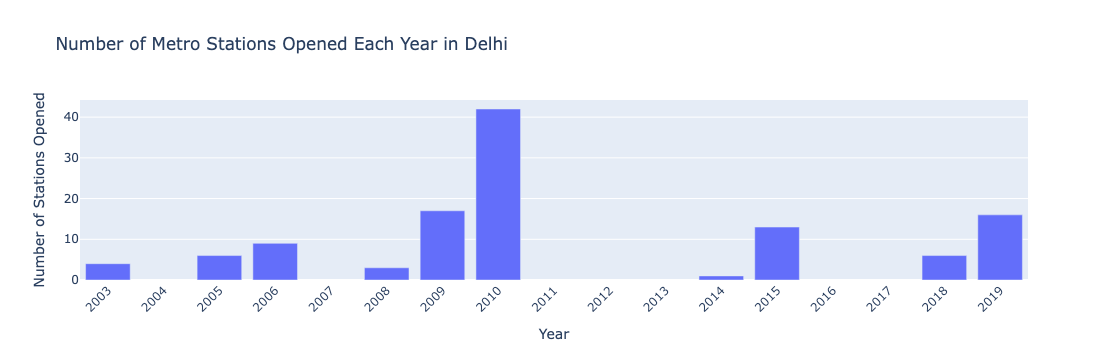

In [19]:
fig.update_layout(xaxis_tickangle=-45, xaxis=dict(tickmode='linear'),
                  yaxis=dict(title='Number of Stations Opened'),
                  xaxis_title="Year")

fig.show()

- This distrubution shows that in which year the number of metro stations are stated.

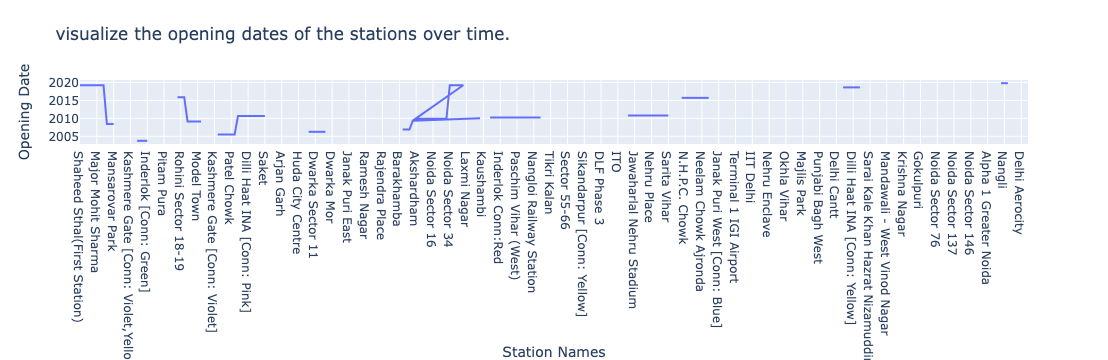

In [20]:
fig = px.line(data, x="Station Names", y="Opening Date", 
              title='visualize the opening dates of the stations over time.')
fig.show()

- This line distribution will tells that how the flow of metro stations openend.

In [21]:
stations_per_line= data['Line'].value_counts()
print(stations_per_line)

Line
Blue line            49
Pink line            38
Yellow line          37
Voilet line          34
Red line             29
Magenta line         25
Green line           21
Aqua line            21
Rapid Metro          11
Blue line branch      8
Orange line           6
Green line branch     3
Gray line             3
Name: count, dtype: int64


- No of stations in each line shows in the above code result.

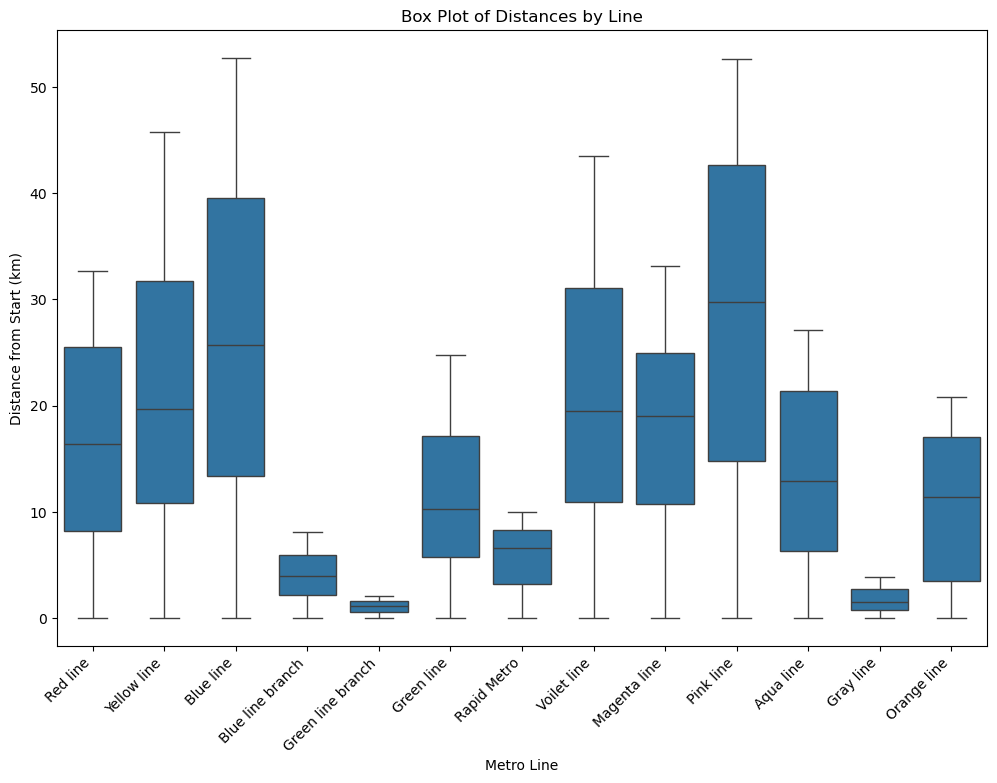

In [22]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='Line', y='Dist. From First Station(km)', data=data)

# Adding labels and title
plt.xlabel('Metro Line')
plt.ylabel('Distance from Start (km)')
plt.title('Box Plot of Distances by Line')

# Rotating x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Show the plot
plt.show()

- This will shows that any outlier is present in the Distance from Start (km) column.

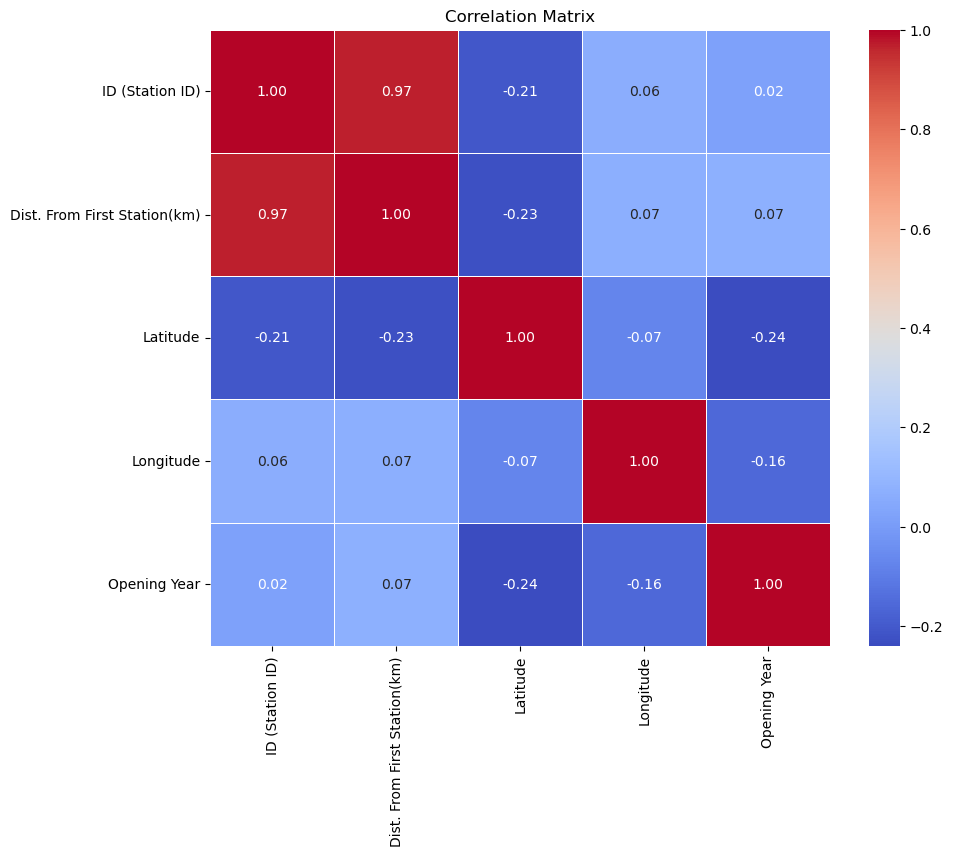

In [23]:
# Select only numeric columns for correlation analysis
numeric_columns = data.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numeric_columns.corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

# Adding title
plt.title('Correlation Matrix')

# Show the plot
plt.show()

- This map will shows the correlation of each column in the dataset. 

In [24]:
# calculating the total distance of each metro line (max distance from start)
total_distance_per_line= data.groupby('Line')['Dist. From First Station(km)'].max()
print(total_distance_per_line)

Line
Aqua line            27.1
Blue line            52.7
Blue line branch      8.1
Gray line             3.9
Green line           24.8
Green line branch     2.1
Magenta line         33.1
Orange line          20.8
Pink line            52.6
Rapid Metro          10.0
Red line             32.7
Voilet line          43.5
Yellow line          45.7
Name: Dist. From First Station(km), dtype: float64


- The total distance of each metro line is show in the above result.

In [25]:
#caluclating the average distance per line
avg_distance_per_line= total_distance_per_line/(stations_per_line-1)
print(avg_distance_per_line)

Line
Aqua line            1.355000
Blue line            1.097917
Blue line branch     1.157143
Gray line            1.950000
Green line           1.240000
Green line branch    1.050000
Magenta line         1.379167
Orange line          4.160000
Pink line            1.421622
Rapid Metro          1.000000
Red line             1.167857
Voilet line          1.318182
Yellow line          1.269444
dtype: float64


- The average distance of each metro line is show in the above result.

In [26]:
line_analysis = pd.DataFrame({
    'Line': stations_per_line.index,
    'Number of Stations': stations_per_line.values,
    'Average Distance Between Stations (km)': avg_distance_per_line})

In [27]:
# sorting the DataFrame by the number of stations
line_analysis = line_analysis.sort_values(by='Number of Stations', ascending=False)

line_analysis.reset_index(drop=True, inplace=True)
print(line_analysis)

                 Line  Number of Stations  \
0           Blue line                  49   
1           Pink line                  38   
2         Yellow line                  37   
3         Voilet line                  34   
4            Red line                  29   
5        Magenta line                  25   
6          Green line                  21   
7           Aqua line                  21   
8         Rapid Metro                  11   
9    Blue line branch                   8   
10        Orange line                   6   
11  Green line branch                   3   
12          Gray line                   3   

    Average Distance Between Stations (km)  
0                                 1.355000  
1                                 1.097917  
2                                 1.157143  
3                                 1.950000  
4                                 1.240000  
5                                 1.050000  
6                                 1.379167  
7        

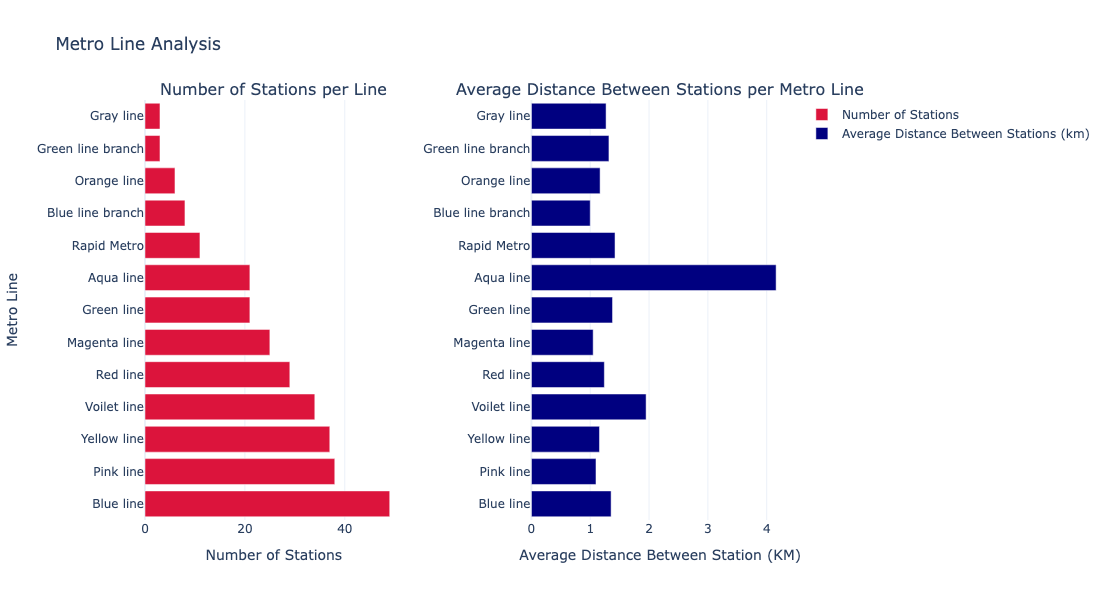

In [28]:
#creating subplots
fig=make_subplots(rows=1, cols=2, subplot_titles=('Number of Stations per Line', 'Average Distance Between Stations per Metro Line'), 
                  horizontal_spacing=0.2)

#plot for Number of Stations per Line
fig.add_trace(go.Bar(y=line_analysis['Line'], x=line_analysis['Number of Stations'], 
                     orientation='h', name= 'Number of Stations', marker_color='crimson'), row=1, col=1)

#plot for Number of Stations per Line
fig.add_trace(go.Bar(y=line_analysis['Line'], x=line_analysis['Average Distance Between Stations (km)'], 
                     orientation='h', name= 'Average Distance Between Stations (km)', marker_color='navy'), 
              row=1, col=2)

#update xaxis properties
fig.update_xaxes(title_text="Number of Stations", row=1, col=1)
fig.update_xaxes(title_text= "Average Distance Between Station (KM)", row=1, col=2)

#update yaxis properties
fig.update_yaxes(title_text='Metro Line', row=1, col=1)
fig.update_yaxes(title_text='', row=1, col=2)

#update layout
fig.update_layout(height=600, width=1200, title_text="Metro Line Analysis", template='plotly_white')

fig.show()

In [29]:
layout_count= data['Layout'].value_counts()

In [30]:
#creating bar plots using plotly
fig = px.bar(x=layout_count.index, y=layout_count.values,
             labels={'x': 'Layout', 'y': 'Number of Stations'},
             title='Distribution of Delhi Metro Station Layouts',
             color=layout_count.index,
             color_continuous_scale='pastel')

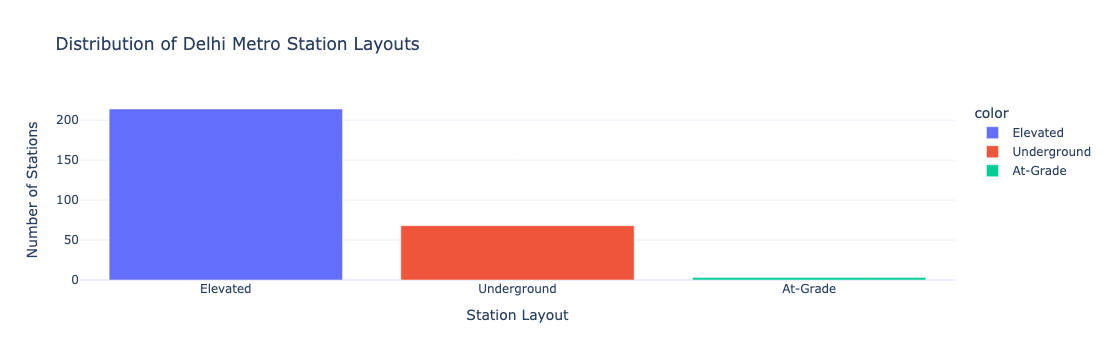

In [31]:
# updating layout for better presentation
fig.update_layout(xaxis_title="Station Layout",
                  yaxis_title="Number of Stations",
                  coloraxis_showscale=False,
                  template="plotly_white")
fig.show()

- This graph will shows the number of metro stations which are Elevated or Underground or At-Grade